just importing libraries and opening file

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#gender = pd.read_csv('/content/data/gender_submission.csv')
#test = pd.read_csv('/content/data/test.csv')

train = pd.read_csv('/content/train.csv')
train.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/train.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


getting info

In [ ]:
train.drop_duplicates()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


deleting duplicate rows (there is no duplicates)

In [ ]:
cat_col = [col for col in train.columns if train[col].dtype == 'object']
num_col = [col for col in train.columns if train[col].dtype != 'object']
print('categorical columns:')
cat_col

categorical columns:


['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [ ]:
print('numerical columns:')
num_col

numerical columns:


['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

numerical and categorical columns

In [ ]:
train[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [ ]:
train[num_col].nunique()

PassengerId    891
Survived         2
Pclass           3
Age             88
SibSp            7
Parch            7
Fare           248
dtype: int64

getting values of them

In [ ]:
train1 = train.drop(columns=['Name', 'Ticket'])
train1

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,71.2833,C85,C
2,3,1,3,female,26.0,0,0,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,53.1000,C123,S
4,5,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,NaN,S
887,888,1,1,female,19.0,0,0,30.0000,B42,S
888,889,0,3,female,NaN,1,2,23.4500,NaN,S
889,890,1,1,male,26.0,0,0,30.0000,C148,C


deleting columns ticket and names since their values will cause problems

In [ ]:
round((train1.isnull().sum()/train1.shape[0])*100,20)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

getting percent of null values

In [ ]:
train1.drop(columns = 'Cabin', inplace = True)
train1.dropna(subset=['Embarked'], axis=0, inplace=True)
train1.shape

(889, 9)

getting shape of file

In [ ]:
train1.fillna(train1.Age.mean(), inplace=True)
train1

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.000000,1,0,7.2500,S
1,2,1,1,female,38.000000,1,0,71.2833,C
2,3,1,3,female,26.000000,0,0,7.9250,S
3,4,1,1,female,35.000000,1,0,53.1000,S
4,5,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0,13.0000,S
887,888,1,1,female,19.000000,0,0,30.0000,S
888,889,0,3,female,29.642093,1,2,23.4500,S
889,890,1,1,male,26.000000,0,0,30.0000,C


In [ ]:
train1.set_index("PassengerId")

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.000000,1,0,7.2500,S
2,1,1,female,38.000000,1,0,71.2833,C
3,1,3,female,26.000000,0,0,7.9250,S
4,1,1,female,35.000000,1,0,53.1000,S
5,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
887,0,2,male,27.000000,0,0,13.0000,S
888,1,1,female,19.000000,0,0,30.0000,S
889,0,3,female,29.642093,1,2,23.4500,S


In [ ]:
train1.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

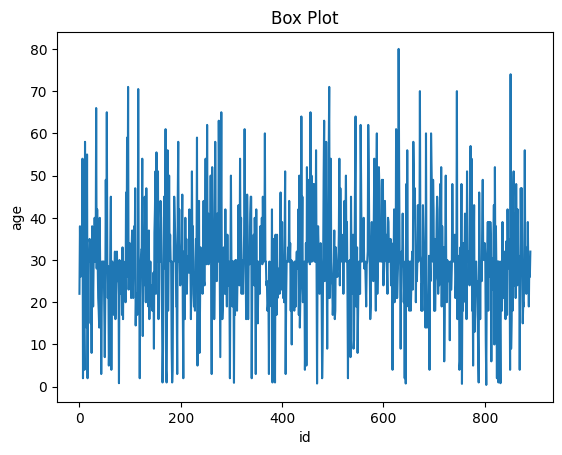

In [ ]:
plt.plot(train1['Age'])
plt.ylabel('age')
plt.xlabel('id')
plt.title('Box Plot')
plt.show()


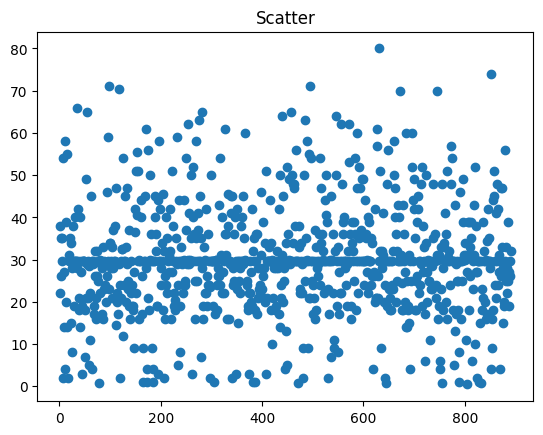

In [ ]:
plt.scatter(train1['PassengerId'],train1['Age'])
plt.title('Scatter')
plt.show()

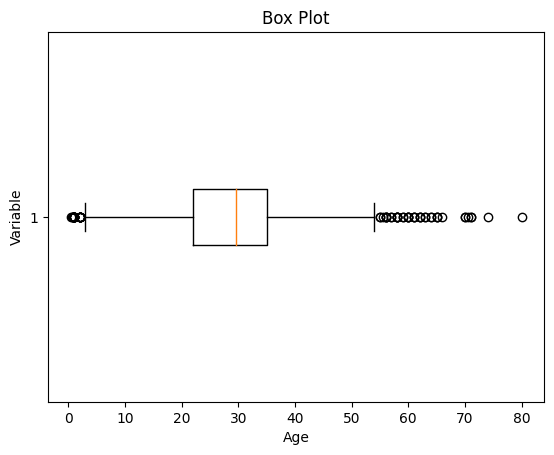

In [ ]:
plt.boxplot(train1['Age'], vert = False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()


graphing 'age' column to see any outliers etc.

In [ ]:
females = train1.loc[train.Sex == "female"]
females.reset_index(drop=True, inplace = True)
females

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,2,1,1,female,38.000000,1,0,71.2833,C
1,3,1,3,female,26.000000,0,0,7.9250,S
2,4,1,1,female,35.000000,1,0,53.1000,S
3,9,1,3,female,27.000000,0,2,11.1333,S
4,10,1,2,female,14.000000,1,0,30.0708,C
...,...,...,...,...,...,...,...,...,...
307,881,1,2,female,25.000000,0,1,26.0000,S
308,883,0,3,female,22.000000,0,0,10.5167,S
309,886,0,3,female,39.000000,0,5,29.1250,Q
310,888,1,1,female,19.000000,0,0,30.0000,S


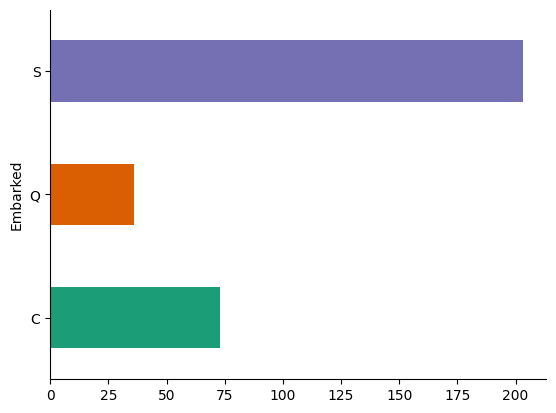

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
females.groupby('Embarked').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
males = train1.loc[train.Sex == "male"]
males.reset_index(drop=True, inplace = True)
males

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.000000,1,0,7.2500,S
1,5,0,3,male,35.000000,0,0,8.0500,S
2,6,0,3,male,29.642093,0,0,8.4583,Q
3,7,0,1,male,54.000000,0,0,51.8625,S
4,8,0,3,male,2.000000,3,1,21.0750,S
...,...,...,...,...,...,...,...,...,...
572,884,0,2,male,28.000000,0,0,10.5000,S
573,885,0,3,male,25.000000,0,0,7.0500,S
574,887,0,2,male,27.000000,0,0,13.0000,S
575,890,1,1,male,26.000000,0,0,30.0000,C


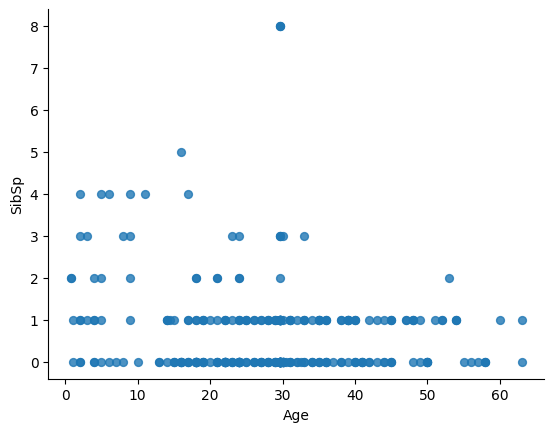

In [ ]:
from matplotlib import pyplot as plt
females.plot(kind='scatter', x='Age', y='SibSp', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

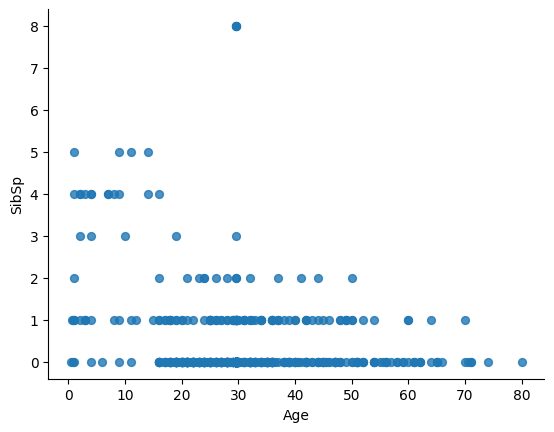

In [ ]:
males.plot(kind='scatter', x='Age', y='SibSp', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

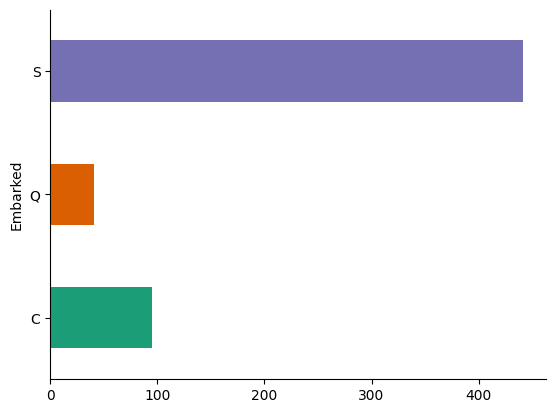

In [ ]:
males.groupby('Embarked').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)


the ratio of the class in which the passenger was to his survival

<Axes: xlabel='Pclass'>

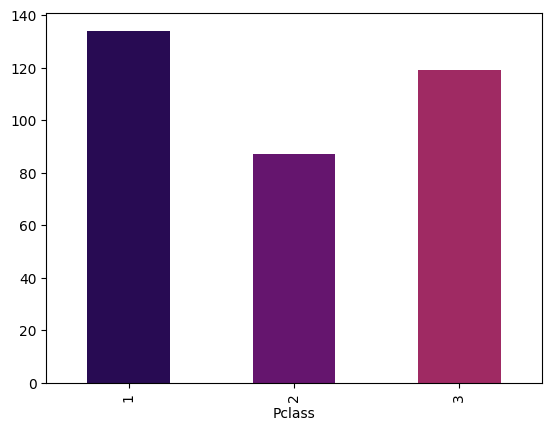

In [ ]:
train_surv = train1.loc[train1.Survived == 1]
train_surv.groupby('Pclass').size().plot(kind='bar', color=sns.palettes.mpl_palette('inferno'))
#plt.gca().spines[['top', 'right',]].set_visible(False)

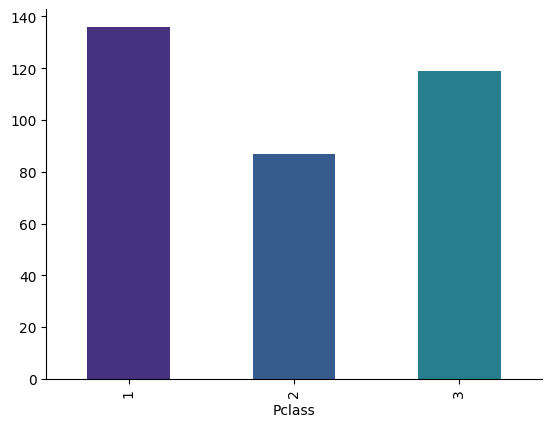

In [ ]:
train_surv = train.loc[train.Survived == 1]
train_surv.groupby('Pclass').size().plot(kind='bar', color=sns.palettes.mpl_palette('viridis'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
from matplotlib import colormaps
list(colormaps)

relation of age of first class passengers to the survivality

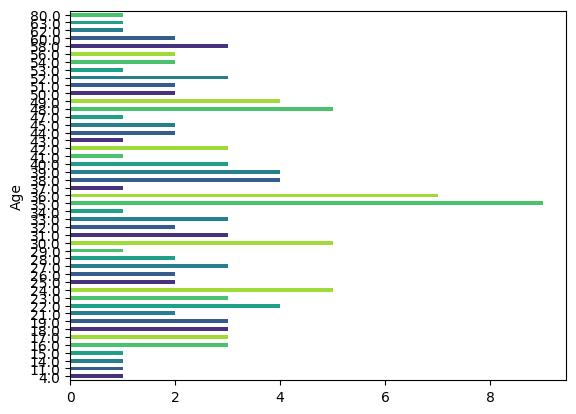

In [ ]:
first = train.loc[(train.Pclass == 1) & (train.Age > 1)]
first_surv = first.loc[first.Survived == 1]
first_surv.groupby('Age').size().plot(kind='barh', color=sns.palettes.mpl_palette('viridis'))
plt.gca().spines[['top', 'right',]].set_visible(True)


relation of age of second class passengers to the survivality

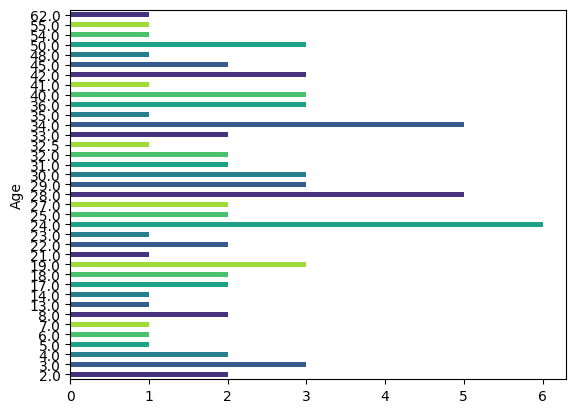

In [ ]:
second = train.loc[(train.Pclass == 2) & (train.Age > 1)]
second_surv = second.loc[second.Survived == 1]
second_surv.groupby('Age').size().plot(kind='barh', color=sns.palettes.mpl_palette('viridis'))
plt.gca().spines[['top', 'right',]].set_visible(True)

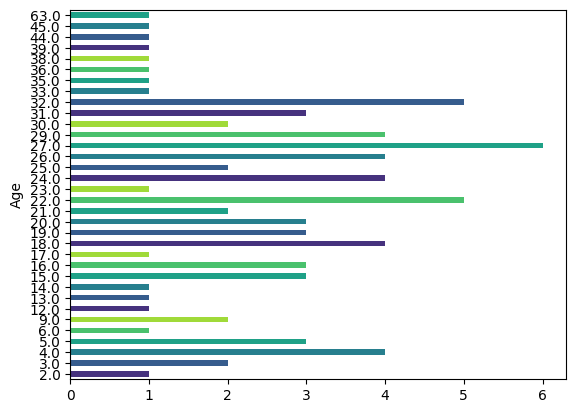

In [ ]:
third = train.loc[(train.Pclass == 3) & (train.Age > 1)]
third_surv = third.loc[third.Survived == 1]
third_surv.groupby('Age').size().plot(kind='barh', color=sns.palettes.mpl_palette('viridis'))
plt.gca().spines[['top', 'right',]].set_visible(True)